# ICE TASK 2: Linear Regression for Medical Insurance Cost Prediction

In this notebook, I will explore a medical insurance dataset and perform exploratory data analysis (EDA). The goal is to understand the data and identify which factors influence medical insurance charges.

After exploring the dataset, I will build a **Linear Regression model** that predicts insurance charges based on different features such as age, BMI, smoking status, and number of children.

This notebook includes:
- Dataset exploration
- Visualisations
- Data preprocessing
- Training a Linear Regression model
- Evaluating model performance

## Task 1: Import Required Libraries

To begin the analysis, I will first import the Python libraries needed for data analysis, visualization, and machine learning.

The main libraries used in this notebook include:

- **Pandas** – used for loading and manipulating datasets
- **NumPy** – used for numerical operations
- **Matplotlib** – used for creating graphs
- **Seaborn** – used for data visualization
- **Scikit-Learn** – used for building and evaluating the machine learning model

In [2]:
# Importing libraries used for data analysis
import pandas as pd
import numpy as np

# Importing libraries used for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Importing machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# This will make the graphs appear inside the notebook
%matplotlib inline

## Task 2: Load and Explore the Dataset

The dataset used in this analysis is the **Medical Insurance Dataset**.  
It contains information about individuals and the medical insurance charges they pay.

The dataset includes the following features:

- **age** – age of the client
- **sex** – gender of the client
- **bmi** – body mass index
- **children** – number of dependents covered by insurance
- **smoker** – whether the person smokes or not
- **region** – geographic region where the client lives
- **charges** – medical insurance cost charged to the client

The target variable for the regression model will be **charges**, because the goal is to predict insurance costs.

In [4]:
# Loading the dataset
insurance = pd.read_csv("insurance.csv")

# Displaying the first 5 rows
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


After loading the dataset, I displayed the first five rows to get an idea of what the data looks like.

Each row represents an individual insurance client, and each column represents a characteristic of that person, such as age, BMI, smoking status, and region.

The final column, **charges**, represents the medical insurance cost that the person pays. This will be the variable that the regression model tries to predict.

## Task 3: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps to better understand the dataset by identifying patterns, trends, and relationships between variables.

Visualizations are useful for seeing how different variables influence medical insurance charges. In this section, I explore how factors such as age, BMI, and smoking status relate to insurance costs.

Understanding these relationships will help determine which variables are important for building the regression model.

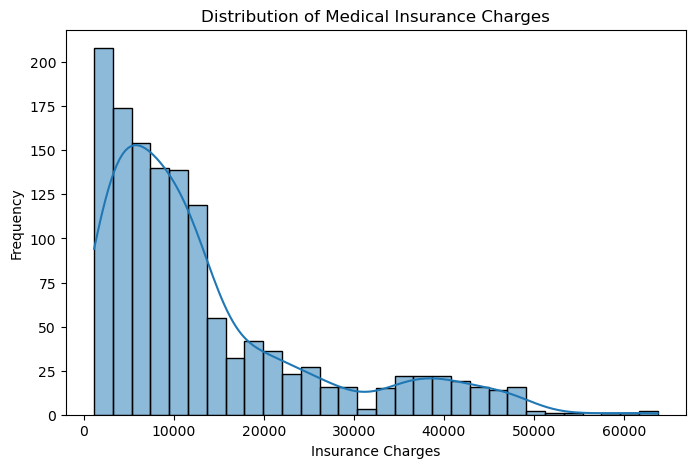

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(insurance['charges'], kde=True)

plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Frequency")

plt.show()

### Interpretation

The distribution plot shows how medical insurance charges are spread across the dataset.

Most individuals have relatively moderate insurance costs, while a smaller number of individuals have very high charges. This creates a right-skewed distribution where the majority of the data is concentrated on the lower end.

This suggests that some factors may significantly increase insurance costs for certain individuals.

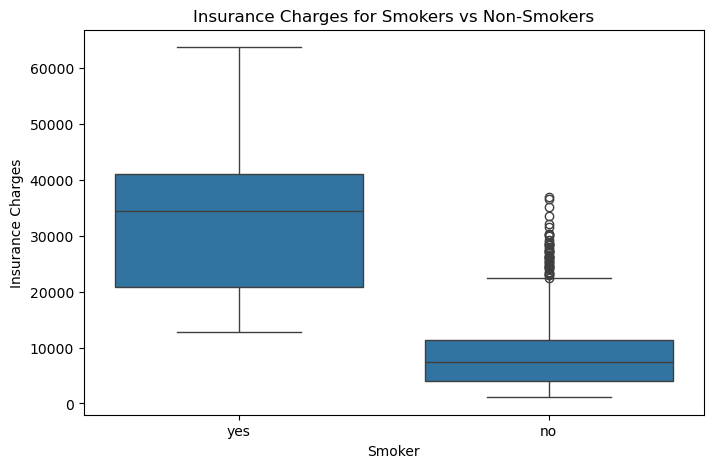

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(x="smoker", y="charges", data=insurance)

plt.title("Insurance Charges for Smokers vs Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Insurance Charges")

plt.show()

### Interpretation

The boxplot shows a strong difference in insurance charges between smokers and non-smokers.

Individuals who smoke tend to have significantly higher insurance costs compared to those who do not smoke. The variation in charges among smokers is also much larger.

This suggests that smoking status is one of the most important variables influencing medical insurance charges.

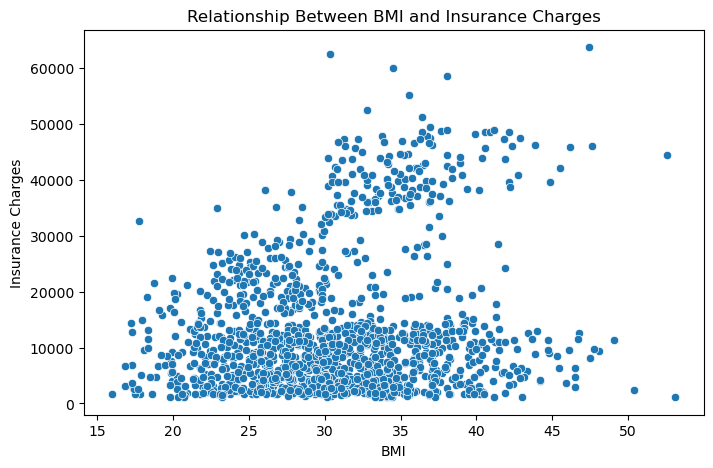

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="bmi", y="charges", data=insurance)

plt.title("Relationship Between BMI and Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

### Interpretation

The scatter plot shows the relationship between BMI and insurance charges.

There appears to be a general trend where individuals with higher BMI values tend to have higher insurance charges. However, the relationship is not perfectly linear, as other factors may also influence the cost.

This suggests that BMI may play a role in predicting insurance charges, but it is likely not the only important factor.

## Task 4: Data Preprocessing

Before training a machine learning model, the dataset needs to be prepared so that it can be used by the algorithm.

Some columns in the dataset contain **categorical values**, such as **sex**, **smoker**, and **region**. Machine learning algorithms cannot process text values directly, so these variables need to be converted into numerical format.

To solve this problem, I convert these categorical variables into **dummy variables**. This creates new columns that represent the categories using binary values (0 or 1).

This process allows the regression model to interpret these variables correctly when making predictions.

In [8]:
# Convert categorical variables into dummy variables
insurance_encoded = pd.get_dummies(insurance, drop_first=True)

# Display the new dataset
insurance_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


After converting the categorical variables into dummy variables, the dataset now contains only numerical values.

For example, the **sex column** is converted into a new column such as **sex_male**, where a value of 1 represents male and 0 represents female.

Similarly, smoking status and regions are converted into numerical columns. This transformation ensures that the dataset can now be used for machine learning algorithms such as Linear Regression.

## Task 5: Define Features and Target Variable

In machine learning, the dataset is divided into **features (X)** and a **target variable (y)**.

The **features** represent the input variables used to make predictions. In this dataset, the features include age, BMI, number of children, smoking status, and region.

The **target variable** is the value that the model attempts to predict. In this case, the target variable is **charges**, which represents the medical insurance cost.

In [10]:
# Define features (X) and target variable (y)

X = insurance_encoded.drop("charges", axis=1)
y = insurance_encoded["charges"]

X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


## Task 6: Split the Dataset into Training and Testing Sets

To evaluate the performance of the model, the dataset is divided into two parts:

- **Training data** – used to train the machine learning model
- **Testing data** – used to evaluate how well the model performs on unseen data

In this analysis, 80% of the data will be used for training and 20% will be used for testing.

In [11]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (1070, 8)
Testing data size: (268, 8)


## Task 7: Train Linear Regression Model

Linear Regression is a machine learning algorithm used to predict numerical values by identifying relationships between variables.

In this step, I train the Linear Regression model using the training dataset. The model learns how the input features influence the insurance charges.

In [12]:
# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Task 8: Make Predictions

After training the model, predictions can be made using the testing dataset.

The model will use the patterns it learned during training to estimate insurance charges for the testing data.

In [13]:
# Make predictions using the test data
y_pred = model.predict(X_test)

# Display first 5 predictions
y_pred[:5]

array([ 8969.55027444,  7068.74744287, 36858.41091155,  9454.67850053,
       26973.17345656])

## Task 9: Evaluate Model Performance

To evaluate the performance of the regression model, several evaluation metrics can be used.

The most common regression evaluation metrics include:

- **Mean Absolute Error (MAE)** – measures the average difference between predicted and actual values.
- **Mean Squared Error (MSE)** – measures the average squared difference between predicted and actual values.
- **R-squared (R²)** – indicates how well the model explains the variation in the target variable.

These metrics help determine how accurate the model is in predicting insurance charges.

In [14]:
# Evaluate the model

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R-squared Score:", r2)

Mean Absolute Error: 4181.19447375365
Mean Squared Error: 33596915.85136146
R-squared Score: 0.7835929767120723


## Task 10: Reflection

### Which variables most strongly influence medical insurance charges?

Based on the exploratory data analysis, smoking status appears to have the strongest influence on insurance charges. Smokers generally have significantly higher insurance costs compared to non-smokers. Age and BMI also seem to influence insurance charges, although their impact appears less dramatic compared to smoking.

### Why might smoking affect insurance costs?

Smoking is associated with a higher risk of serious health conditions such as heart disease, lung disease, and cancer. Because smokers are more likely to require medical treatment, insurance companies charge higher premiums to cover the increased risk.

### What improvements could be made to the model?

Several improvements could be made to enhance the model's predictive performance. For example, additional features such as medical history, exercise habits, or diet could provide more information about a person's health risk. More advanced machine learning models such as Random Forest or Gradient Boosting could also be explored to improve prediction accuracy.